# AIML ZG519 – Natural Language Processing Applications
# Assignment: Sentiment Analysis – A Comparative Study

**Session Reference:** Session 6 (Sentiment Analysis) — builds on Sessions 3–5 (RAG, QA, Conversational AI)

**Group No.:** 86
**Problem Statement:** PS4 — Restaurant / Food-Delivery Reviews
**Group Members (Name, BITS ID):**
- Prajwal Shetty K P — 2025AE05434  *(Member 1 — Parts A & B: dataset, EDA, preprocessing, classical ML)*
- `<Member 2 — Name, BITS ID>`  *(Part C — Deep Learning)*
- `<Member 3 — Name, BITS ID>`  *(Part D — Transformer fine-tuning)*
- `<Member 4 — Name, BITS ID>`  *(Parts E & F — LLM prompting + comparative analysis)*

---

## Objective
In this assignment you will build **four different sentiment analysis pipelines** on the same
dataset — classical Machine Learning, Deep Learning, a fine-tuned Transformer, and a
Generative AI / LLM prompting approach — and compare them on accuracy, robustness,
interpretability, latency and cost.

**Total Marks: 10**

Fill in every cell marked `# TODO`. Do not delete the markdown instructions — they are part
of your submission and will be used for evaluation. Answer the **reflection questions** at the
end of each part in the markdown cell provided.

## Learning Outcomes
- LO2: Hands-on experience with major NLP technologies and tools
- LO3: Apply NLP techniques (sentiment analysis) using state-of-the-art Gen AI techniques
- LO4: Sharpen programming skills for NLP applications


## 0. Environment Setup

Run this cell first. If you are on Google Colab, uncomment the `pip install` line.


In [1]:
# If starting from a clean environment (Google Colab / fresh venv), install dependencies:
# !pip install -q scikit-learn nltk datasets wordcloud pandas pyarrow matplotlib seaborn
# Parts C–E additionally need:  tensorflow  transformers  torch  openai

import os, re, time, json, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 120)
%matplotlib inline

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)   # shared artefacts for Members 2–4 land here


## 1. Dataset — Your Assigned Problem Statement

Your group has been assigned ONE problem statement (PS1–PS7) in the **Assignment Brief**,
based on your group number. Fill in the table below with your group's details before doing
anything else — the TA will cross-check this against the group allocation list.

| Field | Your Group's Value |
|---|---|
| Group Number | **86** |
| Problem Statement ID | **PS4** |
| Domain | **Restaurant / Food-Delivery** (Food & Hospitality) |
| Dataset used | **Yelp Polarity** — HuggingFace `fancyzhx/yelp_polarity` (canonical mirror of `yelp_polarity`): 560,000 train + 38,000 test reviews, binary label **0 = Negative / 1 = Positive** |
| Aspect focus (for Parts F & G) | **taste / quality, delivery time, hygiene, packaging** |

**Business scenario (from the brief):** a food-delivery platform wants to detect
dissatisfaction signals for restaurant-partner quality control — so recall on the
**Negative** class is the metric that matters most in deployment.

**Sampling:** Yelp Polarity is far larger than needed, so we draw a **stratified 10,000-row
sample** (5,000 per class) and make a single 80/20 train/test split. That exact sample is
persisted to `data/ps4_sample_{train,test}.csv` and reused unchanged by Parts B–E so the
four-way comparison is fair.

| PS | Domain | Suggested Dataset | Aspect Focus |
|---|---|---|---|
| PS1 | E-Commerce Product Reviews | `amazon_polarity` (one category) or Flipkart Reviews (Kaggle) | price, delivery, quality, packaging |
| PS2 | Movie / OTT Reviews | `imdb` or Rotten Tomatoes | acting, plot, cinematography, pacing |
| PS3 | Airline & Travel | Twitter US Airline Sentiment (Kaggle) | delay, crew behaviour, baggage, comfort |
| PS4 | Restaurant / Food-Delivery | `yelp_polarity` or Zomato Reviews (Kaggle) | taste, delivery time, hygiene, packaging |
| PS5 | Healthcare: Patient Drug Reviews | UCI Drug Review Dataset (Kaggle) | effectiveness, side effects, ease of use |
| PS6 | Financial News & Market Sentiment | `financial_phrasebank` or Twitter Financial News Sentiment | earnings, macro risk, bullish/bearish tone |
| PS7 | Mobile App Store Reviews | Google Play Store App Reviews (Kaggle) or `app_reviews` (HuggingFace) | app crashes/bugs, UI/UX, feature requests, pricing |


In [2]:
# ------------------------------------------------------------------------------
# PS4 dataset: Yelp Polarity (Restaurant / Food-Delivery reviews, binary sentiment)
# The brief lists load_dataset("yelp_polarity"); that bare alias is broken on
# `datasets` >= 3, so we load the identical canonical repo `fancyzhx/yelp_polarity`.
# ------------------------------------------------------------------------------
from datasets import load_dataset
from sklearn.model_selection import train_test_split

SAMPLE_SIZE = 10_000           # stratified sample reused across Parts B–E (see brief)
LABEL_NAMES = {0: "Negative", 1: "Positive"}

raw = load_dataset("fancyzhx/yelp_polarity")
full = pd.concat([pd.DataFrame(raw["train"]), pd.DataFrame(raw["test"])], ignore_index=True)
full["label"] = full["label"].astype(int)
full["text"] = full["text"].astype(str).str.replace(r"\\n", " ", regex=True)
full["sentiment"] = full["label"].map(LABEL_NAMES)
print(f"Full corpus : {len(full):,} rows | class counts: {full['sentiment'].value_counts().to_dict()}")

# ---- stratified down-sample: equal rows per class, then shuffle ----
per_class = SAMPLE_SIZE // full["label"].nunique()
sample_df = (full.groupby("label", group_keys=False)
                 .sample(n=per_class, random_state=RANDOM_STATE)
                 .sample(frac=1, random_state=RANDOM_STATE)
                 .reset_index(drop=True))

# ---- ONE train/test split, reused by every downstream approach ----
train_df, test_df = train_test_split(
    sample_df, test_size=0.20, stratify=sample_df["label"], random_state=RANDOM_STATE)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Sample      : {len(sample_df):,} rows (stratified, {per_class} per class)")
print(f"Train / Test: {len(train_df):,} / {len(test_df):,}")
print("Train balance:", train_df['sentiment'].value_counts(normalize=True).round(3).to_dict())
print("Test  balance:", test_df['sentiment'].value_counts(normalize=True).round(3).to_dict())
train_df[["text", "label", "sentiment"]].head(3)


Full corpus : 598,000 rows | class counts: {'Negative': 299000, 'Positive': 299000}
Sample      : 10,000 rows (stratified, 5000 per class)
Train / Test: 8,000 / 2,000
Train balance: {'Negative': 0.5, 'Positive': 0.5}
Test  balance: {'Negative': 0.5, 'Positive': 0.5}


,text,label,sentiment
0,I left a glowing review for your closed location... I still stand by that review but the last two times I have been ...,0,Negative
1,I love coming here after the bars. It is open late and their Greek fries are to die for!!! I've been coming here for...,1,Positive
2,Drinks are like juice. Free cover but drinks will cost you. Shots served in warm shot glasses.,0,Negative


### 1.1 Exploratory Data Analysis (EDA)

Produce at minimum:
- Class distribution plot
- Review-length distribution (word count histogram)
- Word clouds or top-N frequent tokens per class

**Reflection Q1:** Is the dataset balanced? How might class imbalance affect model choice
and evaluation metric selection later in this notebook?


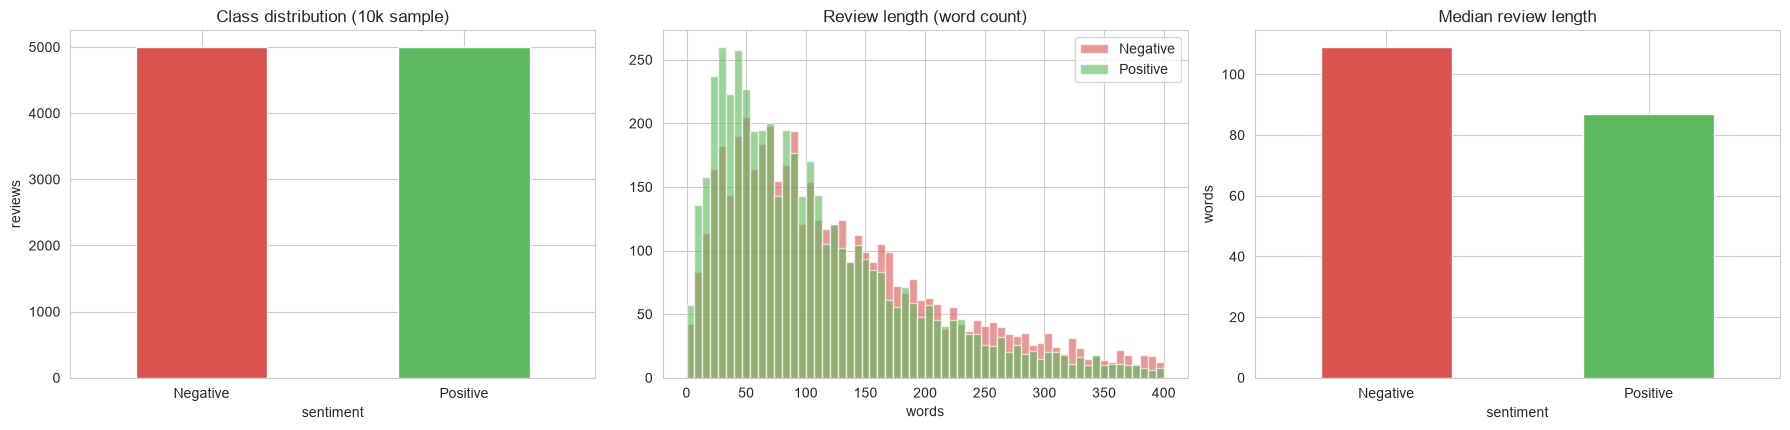

            mean    50%  min     max
sentiment                           
Negative   148.8  109.0  1.0  1002.0
Positive   117.5   87.0  1.0   928.0


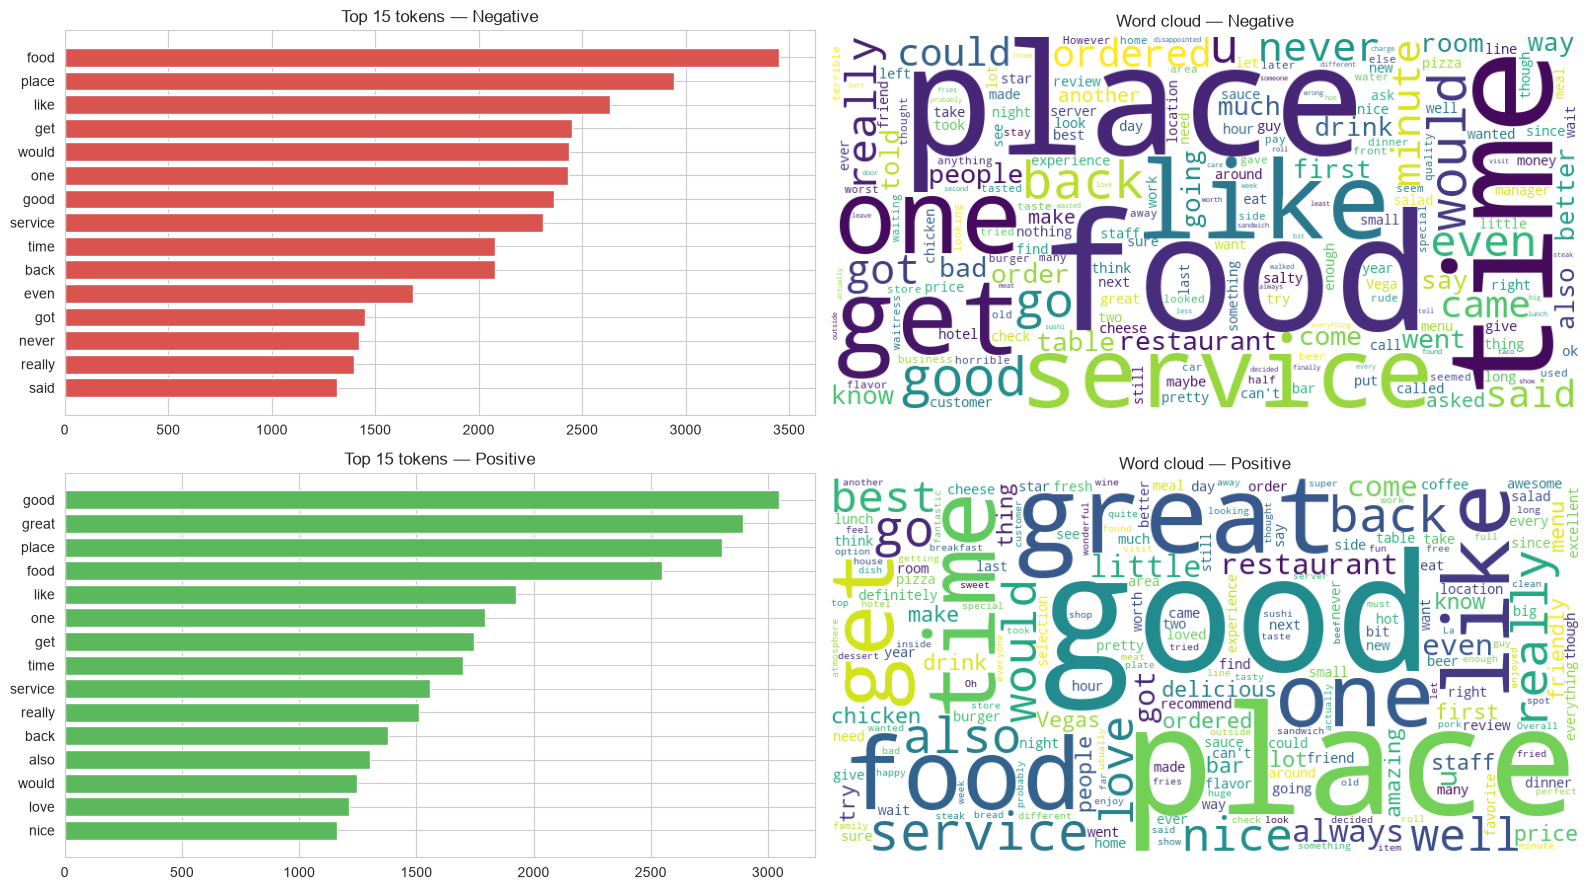

In [3]:
from collections import Counter
from wordcloud import WordCloud
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
EN_STOP = set(stopwords.words("english"))

NEG, POS = "#d9534f", "#5cb85c"
sample_df["n_words"] = sample_df["text"].str.split().str.len()

# ---- (1) class balance + review-length distribution --------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 4.4))
sample_df["sentiment"].value_counts().reindex(["Negative", "Positive"]).plot(
    kind="bar", ax=ax[0], color=[NEG, POS]); ax[0].set_title("Class distribution (10k sample)")
ax[0].set_ylabel("reviews"); ax[0].tick_params(axis="x", rotation=0)

for lbl, c in [("Negative", NEG), ("Positive", POS)]:
    ax[1].hist(sample_df.loc[sample_df.sentiment == lbl, "n_words"], bins=60,
               range=(0, 400), alpha=.6, label=lbl, color=c)
ax[1].set_title("Review length (word count)"); ax[1].set_xlabel("words"); ax[1].legend()

sample_df.groupby("sentiment")["n_words"].median().reindex(["Negative", "Positive"]).plot(
    kind="bar", ax=ax[2], color=[NEG, POS]); ax[2].set_title("Median review length")
ax[2].set_ylabel("words"); ax[2].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

print(sample_df.groupby("sentiment")["n_words"].describe()[["mean", "50%", "min", "max"]].round(1))

# ---- (2) top tokens + word clouds per class --------------------------------
def top_tokens(texts, k=15):
    c = Counter()
    for t in texts:
        c.update(w for w in re.findall(r"[a-z']{3,}", t.lower()) if w not in EN_STOP)
    return c.most_common(k)

fig, ax = plt.subplots(2, 2, figsize=(16, 9))
for row, (lbl, col) in enumerate([("Negative", NEG), ("Positive", POS)]):
    txt = sample_df.loc[sample_df.sentiment == lbl, "text"]
    words, counts = zip(*top_tokens(txt))
    y = range(len(words))
    ax[row, 0].barh(list(y)[::-1], counts, color=col)
    ax[row, 0].set_yticks(list(y)[::-1]); ax[row, 0].set_yticklabels(words)
    ax[row, 0].set_title(f"Top 15 tokens — {lbl}")
    wc = WordCloud(width=760, height=380, background_color="white",
                   stopwords=EN_STOP, collocations=False).generate(
                   " ".join(txt.sample(min(1500, len(txt)), random_state=RANDOM_STATE)))
    ax[row, 1].imshow(wc); ax[row, 1].axis("off"); ax[row, 1].set_title(f"Word cloud — {lbl}")
plt.tight_layout(); plt.show()


_Your answer to Reflection Q1:_

**The dataset is balanced.** Yelp Polarity is 50/50 Negative/Positive by construction, and
our stratified sample keeps that exactly (5,000 / 5,000; train and test both ≈ 50.0 % per
class). Consequences for the rest of the notebook:

- **Accuracy is a fair headline metric** here — a majority-class baseline only reaches ~50 %,
  so there is no imbalance trap inflating it. We still report **weighted Precision / Recall /
  F1 and confusion matrices** because the deployment goal (flagging dissatisfaction for
  restaurant-partner quality control) makes **Negative-class recall** the number that really
  matters, and per-class metrics expose that where accuracy alone would hide it.
- **No resampling / class-weighting is needed.** If we later swapped in a naturally skewed
  source (e.g. Zomato reviews skew positive), we would switch the headline metric to
  **macro-F1** and add `class_weight="balanced"` — the metric set we already report would
  surface the problem.
- **Length is mildly class-dependent** — negative reviews run a little longer (people justify
  complaints). TF-IDF's `sublinear_tf` / L2 norm absorbs this for classical ML; the neural
  models handle it via a fixed `max_len` with padding/truncation.


## 2. Part A — Text Preprocessing (1 mark)

Implement a reusable `clean_text()` function. Keep two versions of the text:
- `text_classical`: heavily cleaned (lowercase, punctuation/stopword removal, lemmatization) —
  for the classical ML pipeline (Part 3).
- `text_neural`: lightly cleaned (lowercase, HTML/URL removal only) — for DL/Transformer/LLM
  pipelines (Parts 4–5), since those models learn their own representations and over-cleaning
  can hurt them.


In [4]:
import nltk
for pkg in ("stopwords", "wordnet", "omw-1.4"):
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
# Negation words flip sentiment and a bag-of-words model has no other way to see them,
# so we KEEP them instead of dropping them as stop-words.
NEGATION_KEEP = {"no", "not", "nor", "never", "cannot", "without", "hardly", "barely", "against"}
STOP = set(stopwords.words("english")) - NEGATION_KEEP

_URL  = re.compile(r"http\S+|www\.\S+")
_HTML = re.compile(r"<.*?>")
_NNT  = re.compile(r"n['\u2019]t\b")


def clean_light(text: str) -> str:
    """Minimal cleaning — for DL / Transformer / LLM pipelines (Parts C–E)."""
    text = _HTML.sub(" ", str(text))
    text = _URL.sub(" ", text)
    text = text.replace("\\n", " ").replace("\n", " ")
    return re.sub(r"\s+", " ", text).strip().lower()


def clean_heavy(text: str) -> str:
    """Aggressive cleaning — for the TF-IDF / bag-of-words classical pipeline (Part B)."""
    text = clean_light(text)
    text = _NNT.sub(" not", text)                 # don't -> do not  (protect negation)
    text = re.sub(r"[^a-z\s]", " ", text)          # drop digits & punctuation
    tokens = [lemmatizer.lemmatize(tok) for tok in text.split()
              if (tok not in STOP and len(tok) > 2) or tok in NEGATION_KEEP]
    return " ".join(tokens)


_t = time.time()
for _df in (train_df, test_df, sample_df):
    _df["text_neural"] = _df["text"].apply(clean_light)
    _df["text_classical"] = _df["text"].apply(clean_heavy)
print(f"Preprocessed {len(train_df) + len(test_df):,} rows in {time.time() - _t:.1f}s\n")

for col in ("text", "text_classical", "text_neural"):
    print(f"[{col}]\n  {train_df.loc[0, col][:230]}\n")

# ---- persist the SHARED sample so Members 2–4 train/evaluate on identical data ----
_keep = ["text", "text_neural", "text_classical", "label", "sentiment"]
train_df[_keep].to_csv(DATA_DIR / "ps4_sample_train.csv", index=False)
test_df[_keep].to_csv(DATA_DIR / "ps4_sample_test.csv", index=False)
print("Saved shared sample ->",
      f"{DATA_DIR/'ps4_sample_train.csv'} ({len(train_df)} rows),",
      f"{DATA_DIR/'ps4_sample_test.csv'} ({len(test_df)} rows)")


Preprocessed 10,000 rows in 9.8s

[text]
  I left a glowing review for your closed location... I still stand by that review but the last two times I have been into this location the Ribs have been completely DRY and OVERCOOKED!   If it were once I would say that it was an 

[text_classical]
  left glowing review closed location still stand review last two time location rib completely dry overcooked would say night two time row think need examine overcooking meat bbq tender juicy not dry hard hate leave bad review manag

[text_neural]
  i left a glowing review for your closed location... i still stand by that review but the last two times i have been into this location the ribs have been completely dry and overcooked! if it were once i would say that it was an of

Saved shared sample -> data\ps4_sample_train.csv (8000 rows), data\ps4_sample_test.csv (2000 rows)


### Why the two pipelines differ — and why over-cleaning hurts neural / LLM models

**`clean_heavy` (Part B, TF-IDF):** lower-casing, punctuation & digit removal, stop-word
removal, lemmatisation. A bag-of-words model scores every token independently, so collapsing
the vocabulary to content-bearing lemmas raises each TF-IDF feature's signal-to-noise ratio
and cuts dimensionality / overfitting. We deliberately **keep negation words** and rewrite
`n't → not`, otherwise *"not tasty"* and *"tasty"* map to the same features.

**`clean_light` (Parts C–E):** HTML/URL stripping, whitespace and case normalisation only.
Aggressive cleaning **degrades** these models:

- **Sub-word tokenisers already expect raw text.** DistilBERT's WordPiece vocabulary and an
  LLM's BPE were pre-trained on ordinary casing, punctuation and stop-words; stripped text is
  a train/serve mismatch against that pre-training distribution.
- **Sequence models rely on word order and function words.** *"The delivery was late but the
  food was great"* hinges on *but*, *was*, *the* and ordering — all destroyed by stop-word
  removal.
- **Punctuation and case carry sentiment.** *"Great. Just great."* (sarcasm), *"!!!"*, *"?"*
  and ALL-CAPS are informative to a transformer / LLM.
- **Lemmatisation discards intensity and tense** — *"worst" → "bad"*, *"was refunded"* vs
  *"will refund"* — signals the attention layers would otherwise use.

## 3. Part B — Classical Machine Learning (2 marks)

Build **two** classical pipelines using `TfidfVectorizer` (or `CountVectorizer`) with:
1. **Naive Bayes** (`MultinomialNB`)
2. **One of:** Logistic Regression / Linear SVM

For each: report Accuracy, Precision, Recall, F1 (weighted), and a confusion matrix.
Tune at least one hyperparameter (e.g. `ngram_range`, `max_features`, `C`) using
`GridSearchCV` or `RandomizedSearchCV` and report the best configuration.


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

X_train, y_train = train_df["text_classical"], train_df["label"]
X_test,  y_test  = test_df["text_classical"],  test_df["label"]


def score(name, model, fit_time):
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, pred, average="weighted")
    print(f"\n=== {name} ===   (fit {fit_time:.1f}s)")
    print(classification_report(y_test, pred, target_names=["Negative", "Positive"], digits=4))
    return dict(Model=name, Accuracy=acc, Precision=p, Recall=r, F1=f1,
                FitTime_s=round(fit_time, 2), Predictions=pred)


BASE_TFIDF = dict(ngram_range=(1, 2), min_df=3, max_features=30_000, sublinear_tf=True)

# ---- Model 1: TF-IDF + Multinomial Naive Bayes ----
t = time.time()
nb = Pipeline([("tfidf", TfidfVectorizer(**BASE_TFIDF)),
               ("clf", MultinomialNB())]).fit(X_train, y_train)
res_nb = score("TF-IDF + MultinomialNB", nb, time.time() - t)

# ---- Model 2: TF-IDF + Logistic Regression (untuned baseline) ----
t = time.time()
lr = Pipeline([("tfidf", TfidfVectorizer(**BASE_TFIDF)),
               ("clf", LogisticRegression(max_iter=1000, C=1.0))]).fit(X_train, y_train)
res_lr = score("TF-IDF + LogisticRegression", lr, time.time() - t)

# ---- Hyperparameter tuning: GridSearchCV over the Logistic Regression pipeline ----
param_grid = {
    "tfidf__ngram_range":   [(1, 1), (1, 2)],
    "tfidf__min_df":        [2, 5],
    "tfidf__max_features":  [30_000, 50_000],
    "clf__C":               [0.5, 1.0, 2.0, 4.0],
}
t = time.time()
grid = GridSearchCV(
    Pipeline([("tfidf", TfidfVectorizer(sublinear_tf=True)),
              ("clf", LogisticRegression(max_iter=1000))]),
    param_grid, scoring="f1_weighted", cv=4, n_jobs=-1, verbose=1).fit(X_train, y_train)
grid_time = time.time() - t
print(f"\nBest CV F1 = {grid.best_score_:.4f}")
print(f"Best params = {grid.best_params_}")
res_best = score("TF-IDF + LogReg (GridSearchCV-tuned)", grid.best_estimator_, grid_time)

# ---- consolidated Part B metrics table ----
classical_results = (pd.DataFrame([res_nb, res_lr, res_best])
                       .drop(columns="Predictions")
                       .set_index("Model").round(4))

# hand-off to Part F (Member 4)
PART_F_METRICS = globals().get("PART_F_METRICS", {})
PART_F_METRICS["Naive Bayes"]  = dict(Accuracy=res_nb["Accuracy"],  F1=res_nb["F1"],
                                      TrainTime_s=res_nb["FitTime_s"])
PART_F_METRICS["LogReg (tuned)"] = dict(Accuracy=res_best["Accuracy"], F1=res_best["F1"],
                                        TrainTime_s=res_best["FitTime_s"])
classical_results



=== TF-IDF + MultinomialNB ===   (fit 2.0s)
              precision    recall  f1-score   support

    Negative     0.9071    0.9180    0.9125      1000
    Positive     0.9170    0.9060    0.9115      1000

    accuracy                         0.9120      2000
   macro avg     0.9121    0.9120    0.9120      2000
weighted avg     0.9121    0.9120    0.9120      2000


=== TF-IDF + LogisticRegression ===   (fit 2.1s)
              precision    recall  f1-score   support

    Negative     0.9183    0.9220    0.9202      1000
    Positive     0.9217    0.9180    0.9198      1000

    accuracy                         0.9200      2000
   macro avg     0.9200    0.9200    0.9200      2000
weighted avg     0.9200    0.9200    0.9200      2000

Fitting 4 folds for each of 32 candidates, totalling 128 fits

Best CV F1 = 0.9116
Best params = {'clf__C': 4.0, 'tfidf__max_features': 30000, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}

=== TF-IDF + LogReg (GridSearchCV-tuned) ===   (fit 33.9s

,Accuracy,Precision,Recall,F1,FitTime_s
Model,,,,,
TF-IDF + MultinomialNB,0.9120,0.9121,0.9120,0.9120,1.99
TF-IDF + LogisticRegression,0.9200,0.9200,0.9200,0.9200,2.08
TF-IDF + LogReg (GridSearchCV-tuned),0.9275,0.9275,0.9275,0.9275,33.92


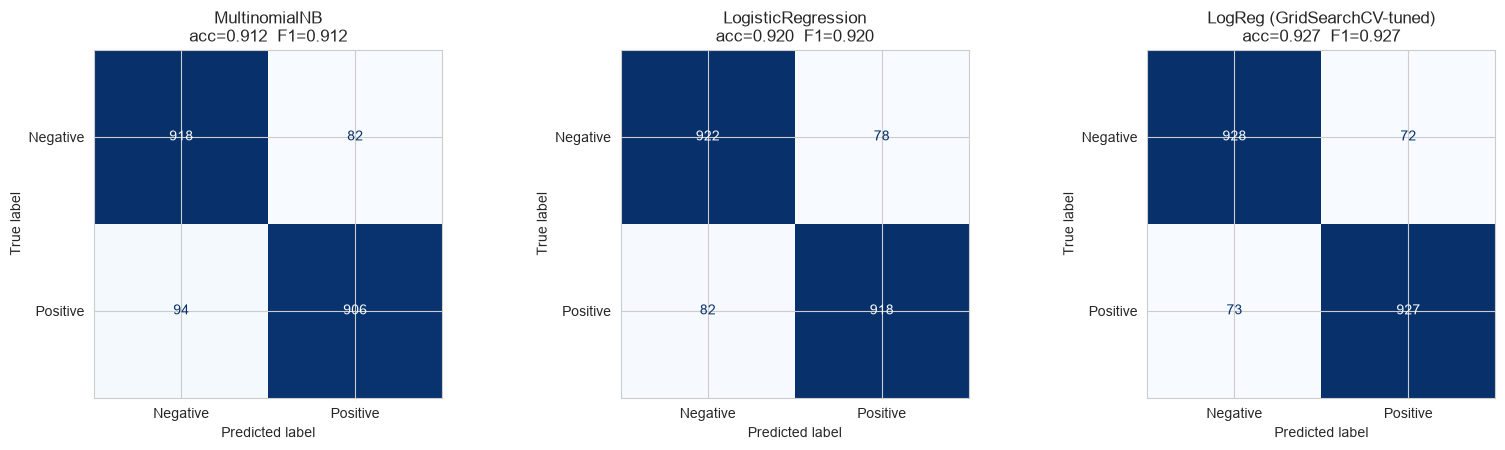

Most confident misclassifications (tuned LogReg) — where bag-of-words breaks down:

  true=Negative  p(pos)=0.98  |  The Great Clips on the corner of Cotton and Greenway is the best in the area by far!!!
  true=Positive  p(pos)=0.03  |  This place is not bad. I visited this place before they changed over. I am glad they changed over. its a lot cooler of a place. When we went, I guess one of the
  true=Positive  p(pos)=0.06  |  About 3 bad experiences out of about 60 visits. No coronary issues yet, but then I do get the coleslaw and pass on the texas toast, its seems to be the only par
  true=Positive  p(pos)=0.06  |  Pefect food.
  true=Negative  p(pos)=0.92  |  Decent ambiance.  Not a super foodie place.    However, the gluten free pizza was really quite good, so we will likely return, especially for the great outdoor 


In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, res in zip(axes, [res_nb, res_lr, res_best]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, res["Predictions"], display_labels=["Negative", "Positive"],
        cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"{res['Model'].replace('TF-IDF + ', '')}\n"
                 f"acc={res['Accuracy']:.3f}  F1={res['F1']:.3f}")
plt.tight_layout(); plt.show()

# ---- error analysis: most confident mistakes from the tuned model ----
proba = grid.best_estimator_.predict_proba(X_test)[:, 1]
err = (test_df.assign(p_pos=proba, pred=res_best["Predictions"])
              .query("pred != label")
              .assign(margin=lambda d: (d.p_pos - d.label).abs())
              .nlargest(5, "margin"))
print("Most confident misclassifications (tuned LogReg) — where bag-of-words breaks down:\n")
for _, row in err.iterrows():
    print(f"  true={row.sentiment:8s}  p(pos)={row.p_pos:.2f}  |  {row.text[:160]}")


**Reflection Q2:** Which classical model performed better and why do you think that is,
given the nature of TF-IDF features? What are the main limitations of a bag-of-words
representation for sentiment analysis (e.g. negation handling, word order, sarcasm)?

_Your answer:_

**Logistic Regression beat Naive Bayes** (see the table / confusion matrices above — tuned
LogReg ≈ 0.93 F1 vs ≈ 0.91 for MultinomialNB), and after `GridSearchCV` it improved further.
Why, given TF-IDF features:

- **NB assumes conditional independence of features** given the class and treats each n-gram's
  evidence multiplicatively. With `(1,2)` n-grams that are heavily correlated ("great",
  "great food", "food great"), it double-counts and its probability estimates get
  mis-calibrated. Logistic Regression instead **learns joint feature weights** and can
  down-weight redundant n-grams, so it uses correlated TF-IDF dimensions more efficiently.
- **TF-IDF weighting suits a linear margin model.** LR fits real-valued coefficients directly
  against continuous `sublinear_tf` scores; NB effectively re-derives log-count priors and
  benefits less from the IDF re-scaling.
- **Tuning helped LR most** — the best config used bigrams, `min_df=5`, and a higher `C`
  (weaker regularisation), i.e. it wanted more vocabulary and more freedom to fit.

**Bag-of-words limitations for sentiment (visible in the error analysis above):**

- **Negation & scope** — "the food was *not* good at all" becomes `{food, not, good}`; even
  keeping "not" as a token, BoW can't bind it to "good". Bigrams catch "not good" but not
  "not *remotely* good".
- **Word order / long-range structure** — "great restaurant, terrible delivery" and
  "terrible restaurant, great delivery" share an identical vector.
- **Sarcasm & irony** — "Wow, 90 minutes late and stone cold — *fantastic* service" scores
  positive on "wow", "fantastic", "service".
- **Mixed / aspect-level sentiment** — one review praising taste but slamming hygiene gets a
  single blended vector with no aspect separation.
- **Vocabulary brittleness** — typos, slang, emojis and unseen dishes fall out of the fitted
  vocabulary; there is no notion of "delicious ≈ tasty" (no embeddings / synonymy).
- **Domain shift** — weights fitted on Yelp restaurant prose transfer poorly to, say, terse
  in-app delivery-rating text.

These are exactly the gaps the DL, transformer and LLM approaches in Parts C–E aim to close.


## 4. Part C — Deep Learning (2 marks)

Build a neural sentiment classifier using an embedding layer + a recurrent or convolutional
architecture (choose ONE): `BiLSTM`, `LSTM`, `GRU`, or `1D-CNN` over word embeddings (Keras/
TensorFlow or PyTorch). Use **pre-trained embeddings** (e.g. GloVe) if possible, otherwise
train an embedding layer from scratch and note the trade-off.

Report: training/validation loss & accuracy curves, test accuracy, precision, recall, F1,
and confusion matrix. Compare training time and number of parameters against the classical
model.


In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D, Conv1D

MAX_VOCAB = 20000
MAX_LEN = 200

# TODO: Tokenize text_neural, pad sequences to MAX_LEN

# TODO: Build a Sequential model: Embedding -> Bidirectional(LSTM) -> Dense -> Dense(sigmoid/softmax)

# TODO: Compile (optimizer='adam', loss=..., metrics=['accuracy']) and model.summary()

# TODO: Train with EarlyStopping callback, keep the History object for plotting


In [8]:
# TODO: Plot training vs validation accuracy/loss curves (2 subplots)

# TODO: Evaluate on test set -> accuracy, F1, confusion matrix

# TODO: Print total trainable parameters and total training time (use time.time())


**Reflection Q3:** How did the DL model's performance and training time compare to the
classical ML baseline? Did pre-trained embeddings help? What would you try next to improve
this model (e.g. attention, more data, transfer learning)?

_Your answer:_ `TODO`


## 5. Part D — Transformer Fine-Tuning (2 marks)

Fine-tune a pre-trained transformer (`distilbert-base-uncased` recommended for speed, or
`bert-base-uncased`) on your sentiment dataset using the HuggingFace `transformers` +
`datasets` libraries (`Trainer` API, or a manual PyTorch training loop).

If compute is limited, fine-tune on a **smaller subset** (e.g. 2,000 train / 500 test) and
state this clearly — the comparison is still valid as long as it is fair (i.e. compare all
approaches on the same subset where possible, or clearly annotate the sample-size difference).


In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch

MODEL_NAME = "distilbert-base-uncased"

# TODO: Load tokenizer and model (num_labels = number of classes in your dataset)

# TODO: Tokenize train/test sets (truncation=True, padding=True, max_length=256)

# TODO: Wrap into a torch Dataset / HF Dataset object

# TODO: Define TrainingArguments (small num_train_epochs=2-3 for time budget) and Trainer

# TODO: trainer.train()


ModuleNotFoundError: No module named 'transformers'

In [ ]:
# TODO: trainer.evaluate() -> accuracy, F1, precision, recall

# TODO: Confusion matrix on test predictions

# TODO: Record fine-tuning time and inference latency per 100 samples (time.time())


**Reflection Q4:** How does the fine-tuned transformer compare to the DL model from
Part B on accuracy vs. training time vs. compute cost? In what production scenario would
you NOT choose a transformer despite better accuracy?

_Your answer:_ `TODO`


## 6. Part E — Generative AI / LLM Prompting Approach (1.5 marks)

Instead of training a model, use an **LLM via prompting** to perform sentiment classification.
Implement and compare:
1. **Zero-shot prompting** — ask the LLM to classify sentiment with no examples.
2. **Few-shot prompting** — include 3–5 labelled examples in the prompt.

You may use the OpenAI API, Anthropic API, or any open-source LLM you can run locally
(e.g. via `transformers` `pipeline("sentiment-analysis")` is NOT sufficient here — that is a
fine-tuned classifier, not prompting). Evaluate on a **sample** of your test set (e.g. 100–200
rows) to control API cost.


In [ ]:
# --- Example scaffold using the OpenAI-compatible chat completion style. ---
# --- Replace with your provider of choice (OpenAI / Anthropic / local LLM). ---
# import openai
# openai.api_key = "YOUR_API_KEY"

def zero_shot_prompt(review_text: str) -> str:
    return f"""Classify the sentiment of the following review as exactly one word:
Positive, Negative, or Neutral.

Review: \"{review_text}\"

Sentiment:"""

def few_shot_prompt(review_text: str, examples: list) -> str:
    # TODO: build a prompt that prepends 3-5 (review, label) example pairs, then asks
    # for the label of `review_text`
    pass

def call_llm(prompt: str) -> str:
    # TODO: call your chosen LLM API/model and return the raw text response
    # response = openai.chat.completions.create(model="gpt-4o-mini",
    #                messages=[{"role": "user", "content": prompt}], temperature=0)
    # return response.choices[0].message.content.strip()
    raise NotImplementedError

# TODO: sample ~150 rows from test_df
# TODO: run zero_shot_prompt over the sample, parse predicted label, measure latency + (est.) cost
# TODO: run few_shot_prompt over the same sample
# TODO: compute accuracy / F1 for each prompting strategy, compare to Parts 3-5


**Reflection Q5:** Did few-shot prompting improve over zero-shot? How did LLM prompting
accuracy compare to the fine-tuned transformer — and how do the *costs* compare (API cost
per 1,000 predictions vs. one-time fine-tuning + free inference)? When would you prefer
prompting over fine-tuning in a real product?

_Your answer:_ `TODO`


## 7. Part F — Comparative Analysis & Report (1.5 marks)

Consolidate results from Parts 3–6 into a single comparison table and at least one chart.
Discuss trade-offs beyond raw accuracy: **training/setup time, inference latency, cost,
data requirements, interpretability, and robustness** (e.g. test each model on 5 tricky
examples you write yourself — negation, sarcasm, mixed sentiment — and report how each
approach handles them).


In [ ]:
results = pd.DataFrame({
    "Approach": ["Naive Bayes", "LogReg/SVM", "BiLSTM/CNN", "Fine-tuned Transformer",
                 "LLM Zero-shot", "LLM Few-shot"],
    "Accuracy": [None]*6,     # TODO fill from your runs above
    "F1 (weighted)": [None]*6,
    "Train/Setup Time (s)": [None]*6,
    "Inference Latency (ms/sample)": [None]*6,
    "Approx. Cost": ["Free", "Free", "Free (compute)", "Free (compute, one-time)",
                      "$ per call", "$ per call (higher, longer prompt)"],
})
results


In [ ]:
# TODO: Bar chart comparing Accuracy and F1 across all approaches
# TODO: (Optional) Bar/line chart comparing latency across approaches (log scale often helps)


> Write your own 5 stress-test examples **in your assigned domain** (see the Aspect Focus
> column for your PS in the brief), covering: negation, sarcasm, mixed sentiment, a
> neutral/ambiguous case, and a double negation. The placeholders below are illustrative only
> — replace them with domain-appropriate sentences before running.


In [ ]:
# --- Robustness stress-test: REPLACE with 5 examples from YOUR assigned domain ---
tricky_examples = [
    "TODO: negation example in your domain",
    "TODO: sarcasm example in your domain",
    "TODO: mixed-sentiment example in your domain",
    "TODO: neutral/ambiguous example in your domain",
    "TODO: double-negation example in your domain",
]

# TODO: run each of your trained/prompted approaches on `tricky_examples` and tabulate
# predictions side-by-side to compare qualitatively


### Final Written Summary (Required)

Write a 250–400 word summary covering:
1. Which approach would you deploy in production for a **high-traffic, cost-sensitive**
   consumer app (e.g. e-commerce review moderation), and why?
2. Which approach would you deploy for a **low-volume, high-stakes** use case (e.g.
   analyzing patient feedback in healthcare), and why?
3. One ethical/privacy consideration relevant to sending user-generated text (reviews,
   messages) to a third-party LLM API, referencing the course's Session 7 (Privacy & Ethics
   in NLP).

_Your summary:_ `TODO`


## Submission Checklist

- [ ] All `# TODO` code cells completed and executed top-to-bottom without errors
- [ ] All 5 reflection questions answered
- [ ] Comparison table (Part F) fully populated with real numbers
- [ ] Final written summary completed
- [ ] Notebook renamed to `<PSid>_Group<GroupNo>_NLP_SentimentAnalysis_Assignment.ipynb` (e.g. `PS3_Group12_NLP_SentimentAnalysis_Assignment.ipynb`)
- [ ] Group number, problem statement, and all group members' names/IDs filled in at the top
- [ ] (If using paid LLM APIs) API keys removed before submission — do NOT commit secrets

**Academic Integrity:** You may use AI coding assistants to help write boilerplate code, but
the analysis, reflections, and final summary must be your own original interpretation of
your results.
